# Random Forests

In this notebook we will do some Random Forest modeling for our data.

In [2]:
import pandas as pd
import copy
import numpy as np

## Data preprocessing

#### Import the data

In [4]:
ogdf = pd.read_csv('./data/final_dataframes/main_training_dataframe.csv')
houroutdf=copy.deepcopy(ogdf)
houroutdf = houroutdf.rename(columns={'Wind': 'Wind_Power'}) #renaming target variable
houroutdf

,Unnamed: 0,time,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind_Power,Year,MonthDay
0,0,2019-01-01 00:00:00,-7.4,81,17.9,146,-5.7,87,12.4,100,...,88,13.0,132,-5.6,84,18.8,144,1933.0,2019,01-01
1,1,2019-01-01 01:00:00,-7.0,80,18.9,145,-5.8,87,13.6,102,...,87,14.6,130,-5.8,84,19.2,142,1996.0,2019,01-01
2,2,2019-01-01 02:00:00,-7.1,80,21.3,146,-5.9,88,12.9,103,...,89,16.0,121,-5.8,83,17.9,142,1936.0,2019,01-01
3,3,2019-01-01 03:00:00,-6.8,80,22.2,148,-5.9,90,15.9,103,...,87,16.2,122,-6.0,84,15.0,136,2023.0,2019,01-01
4,4,2019-01-01 04:00:00,-6.8,81,22.4,143,-5.9,90,15.6,109,...,86,16.1,114,-6.3,86,15.8,131,2147.0,2019,01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35059,2022-12-31 19:00:00,3.1,92,7.7,217,1.1,94,5.6,45,...,97,4.9,234,1.8,98,4.6,198,145.0,2022,12-31
35060,35060,2022-12-31 20:00:00,2.6,97,2.5,188,1.0,95,4.6,51,...,98,1.1,90,2.2,100,5.1,188,118.0,2022,12-31
35061,35061,2022-12-31 21:00:00,2.9,96,2.7,203,0.8,96,6.0,17,...,99,1.8,90,3.4,99,2.2,189,31.0,2022,12-31
35062,35062,2022-12-31 22:00:00,3.8,94,3.1,54,0.6,96,5.2,335,...,99,3.3,96,3.0,100,1.8,127,33.0,2022,12-31


In [5]:
#now we need to take the entries in 'Wind_power' and then add n=24 of them together for power one day ahead
n=24
dayoutdf = copy.deepcopy(houroutdf)
dayoutdf['Wind_Power'] = dayoutdf['Wind_Power'].rolling(window=n).sum().shift(-n) #this replaces 'Wind' time t with the sum of the entries in 'Wind' at t+1,... t+24
dayoutdf = dayoutdf.iloc[:-24] #removing last 24 entries

#### Feature selection
Here I will remove some features and modify some other ones.

In [6]:
#removing categorical variables
dayoutdf_no_categorical = copy.deepcopy(dayoutdf)
dayoutdf_no_categorical = dayoutdf_no_categorical.drop(columns=['MonthDay', 'time'])
dayoutdf_no_categorical = dayoutdf_no_categorical.drop(columns=['Unnamed: 0', 'Year']) #removing some other variables I don't want/need right now
dayoutdf_no_categorical

,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,relative_humidity_2m_2,...,wind_direction_10m_31,temperature_2m_34,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind_Power
0,-7.4,81,17.9,146,-5.7,87,12.4,100,-13.4,85,...,145,-11.1,88,13.0,132,-5.6,84,18.8,144,53069.0
1,-7.0,80,18.9,145,-5.8,87,13.6,102,-13.6,87,...,147,-10.4,87,14.6,130,-5.8,84,19.2,142,53355.0
2,-7.1,80,21.3,146,-5.9,88,12.9,103,-14.1,89,...,136,-10.9,89,16.0,121,-5.8,83,17.9,142,53663.0
3,-6.8,80,22.2,148,-5.9,90,15.9,103,-12.8,86,...,128,-10.0,87,16.2,122,-6.0,84,15.0,136,53689.0
4,-6.8,81,22.4,143,-5.9,90,15.6,109,-11.9,88,...,129,-9.4,86,16.1,114,-6.3,86,15.8,131,53600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,7.1,83,20.2,202,7.0,83,17.9,214,-0.6,93,...,224,2.9,92,13.8,173,7.6,82,20.7,220,36696.0
35036,7.8,81,21.1,205,6.9,83,15.0,204,-1.3,96,...,221,2.4,94,14.1,167,8.4,81,21.5,220,34296.0
35037,6.6,83,16.1,219,5.8,85,10.8,195,-0.7,95,...,226,2.3,94,13.1,172,7.0,85,20.7,230,31854.0
35038,7.6,82,19.6,221,5.5,86,9.4,198,-0.2,94,...,232,2.4,94,11.7,162,7.2,85,25.0,224,29509.0


In [7]:
#changing wind direction to (x,y) coordinates, removing times, unnamed column, year
dayoutdf_numerical = copy.deepcopy(dayoutdf_no_categorical)
for i in range(1, 40):
    col = f"wind_direction_10m_{i}"
    radians = np.deg2rad(dayoutdf_no_categorical[col])
    dayoutdf_numerical[f"wind_direction_10m_x_{i}"] = np.cos(radians)
    dayoutdf_numerical[f"wind_direction_10m_y_{i}"] = np.sin(radians)

dayoutdf_numerical  = dayoutdf_numerical [[c for c in dayoutdf_numerical .columns if c != 'Wing_Power'] + ['Wind_Power']]
dayoutdf_numerical 

,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,relative_humidity_2m_2,...,wind_direction_10m_y_35,wind_direction_10m_x_36,wind_direction_10m_y_36,wind_direction_10m_x_37,wind_direction_10m_y_37,wind_direction_10m_x_38,wind_direction_10m_y_38,wind_direction_10m_x_39,wind_direction_10m_y_39,Wind_Power
0,-7.4,81,17.9,146,-5.7,87,12.4,100,-13.4,85,...,0.573576,-0.866025,0.500000,-0.777146,0.629320,-0.809017,0.587785,0.292372,-0.956305,53069.0
1,-7.0,80,18.9,145,-5.8,87,13.6,102,-13.6,87,...,0.669131,-0.906308,0.422618,-0.766044,0.642788,-0.788011,0.615661,0.069756,-0.997564,53355.0
2,-7.1,80,21.3,146,-5.9,88,12.9,103,-14.1,89,...,0.743145,-0.891007,0.453990,-0.707107,0.707107,-0.788011,0.615661,-0.258819,-0.965926,53663.0
3,-6.8,80,22.2,148,-5.9,90,15.9,103,-12.8,86,...,0.788011,-0.838671,0.544639,-0.694658,0.719340,-0.719340,0.694658,-0.615661,-0.788011,53689.0
4,-6.8,81,22.4,143,-5.9,90,15.6,109,-11.9,88,...,0.848048,-0.788011,0.615661,-0.707107,0.707107,-0.656059,0.754710,-0.882948,-0.469472,53600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,7.1,83,20.2,202,7.0,83,17.9,214,-0.6,93,...,-0.358368,-0.990268,-0.139173,-0.719340,-0.694658,-0.766044,-0.642788,-0.920505,-0.390731,36696.0
35036,7.8,81,21.1,205,6.9,83,15.0,204,-1.3,96,...,-0.342020,-0.965926,-0.258819,-0.766044,-0.642788,-0.766044,-0.642788,-0.891007,-0.453990,34296.0
35037,6.6,83,16.1,219,5.8,85,10.8,195,-0.7,95,...,-0.500000,-0.956305,-0.292372,-0.819152,-0.573576,-0.642788,-0.766044,-0.809017,-0.587785,31854.0
35038,7.6,82,19.6,221,5.5,86,9.4,198,-0.2,94,...,-0.573576,-0.906308,-0.422618,-0.798636,-0.601815,-0.719340,-0.694658,-0.798636,-0.601815,29509.0


#### PCA and Scaling

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
#scale the features and do PCA on them
# Function from earlier
features = dayoutdf_numerical.drop(columns=['Wind_Power'])
target = dayoutdf_numerical.iloc[:, -1]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

dayoutdf_numerical_scaled = pd.DataFrame(features_scaled, columns=features.columns)
dayoutdf_numerical_scaled['Wind_Power'] = target.values

In [10]:
#implementing PCA on features
n= 6 #this is the number of featur
pca =  PCA(n_components = n)
features_pca = pca.fit_transform(features_scaled)
pca_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
dayoutdf_pca = pd.DataFrame(features_pca, columns=pca_columns, index=dayoutdf_numerical_scaled.index)
dayoutdf_pca['Wind_Power'] = target.values
dayoutdf_pca

,PC1,PC2,PC3,PC4,PC5,PC6,Wind_Power
0,7.608006,-9.766968,1.920340,-5.171582,-3.219251,-1.766430,53069.0
1,7.888156,-9.903449,2.206609,-5.424365,-2.509406,-2.108743,53355.0
2,8.102388,-10.388285,2.014124,-5.131846,-1.304894,-2.691581,53663.0
3,8.281289,-10.560539,1.804169,-4.939909,-0.322440,-2.967131,53689.0
4,8.373783,-10.668014,2.066158,-5.003527,0.471792,-3.107829,53600.0
...,...,...,...,...,...,...,...
35035,3.810989,-0.476562,8.901158,-1.848179,-2.230618,-0.431292,36696.0
35036,3.693032,-0.472809,9.215485,-2.286223,-2.107591,-1.323882,34296.0
35037,3.316171,-0.381383,8.621304,-1.417934,-2.957484,-1.640509,31854.0
35038,2.525991,0.079896,8.460148,-1.157779,-3.278697,-2.251446,29509.0


## Building a model, naively

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt


#### Defining training set and test set

In [105]:
#set the data you want to use
df = dayoutdf_pca

In [106]:
#make training and test sets, right now I want to train on one year and predict on the next day
df = df.head(8760) #looking at first year
X = df[[col for col in df.columns if col != "Wind_Power"]]
y = df["Wind_Power"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=614)



#### Dummy model

In [107]:
#dummy regressor
dummy = DummyRegressor(strategy='mean')  # You can also use strategy='constant', constant=YOUR_VALUE
dummy.fit(X_train, y_train)

# Predictions
y_pred_dummy = dummy.predict(X_test)

# Evaluation
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_dummy))
print("R^2 Score:", r2_score(y_test, y_pred_dummy))


MAPE: 1.1404022246154453
R^2 Score: -0.002280572588439833


#### Random Forest

In [108]:
# Initialize and train Random Forest model
model = RandomForestRegressor(n_estimators=100, max_depth=100, random_state=614)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAPE: {mape:.4f}")
print(f"R² Score: {r2:.4f}")

MAPE: 0.3790
R² Score: 0.7102


This is not in general reflective of how the model would be used in practice but it suggests ourd data has some predictive power and that maybe Random forest aren't hopeless.

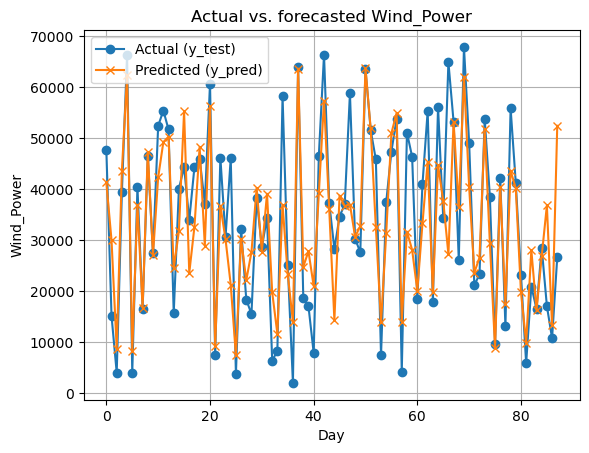

In [110]:
x = np.arange(len(y_test))
plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Day')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()

#### A model with Time Series Cross Validation

In [111]:
from sklearn.model_selection import TimeSeriesSplit #this doesn't quite do what I want

In [112]:
#defining some data
df = dayoutdf_pca
X = df.drop(columns=['Wind_Power'])
y = df['Wind_Power']


The code below does the following, trains a random forest on one year of data. Then it predicts the day ahead power for the next day. Then it trains again on a year and one day of data and makes a new prediction. This then generates data points for each day. The error measure then compares these to the actual values for each of those days.

In [120]:
# training Parameters
train_start = 8 #in hours, we're starting at 8am EST in Quebec
train_days =  365
test_days = 30

#model hyperparameters
estimators = 50
depth = 100
randomstate= 614

#some parameters and things to initialize
train_hours = 24 * (train_days)
test_hours = 24 * (test_days)
mape_scores = []
r2_scores = []
y_pred = np.array([])

# Loop over time windows
for j in range(0, test_days):
    train_end = train_start + train_hours


    X_train = X.iloc[train_start:train_end + (j*24)]
    y_train = y.iloc[train_start:train_end+ (j*24)]
    
   # X_test = X.iloc[train_end+ (j*24):train_end+ ((j+1)*24)]


    model = RandomForestRegressor(n_estimators=estimators, max_depth=depth, random_state=randomstate)
    model.fit(X_train, y_train)
    
    y_jth_pred = model.predict(X.iloc[[train_end+ ((j+1)*24)]])


    y_pred = np.append(y_pred, y_jth_pred)
print(y_pred)

[38175.   14846.58 36123.52 30883.4  36019.04 28769.64 28631.6  49338.7
 50832.74 33340.66 41076.5  26816.26 10499.64 23578.06 17034.88 63399.7
 40193.36 45858.22 41497.32 44569.08 26831.54 33478.42 16808.04 41383.24
 52355.36 37075.58 21124.4  35651.56 33337.74 40900.12]


 MAPE: 1.1167
R2: -0.6769


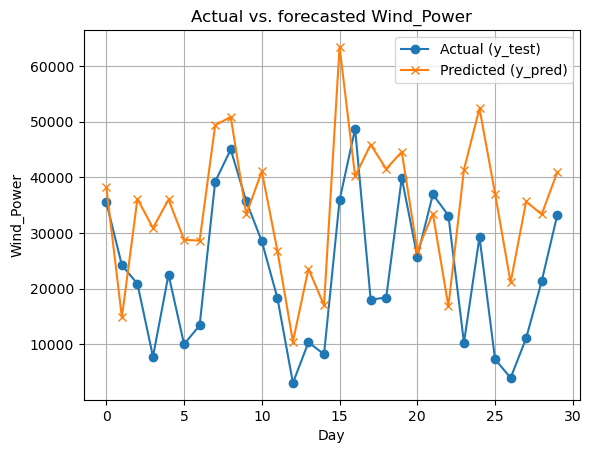

In [121]:
#test accuracy
y_test = y[train_end:]
y_test = y_test[::24]
y_test = y_test[:test_days]

mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f' MAPE: {mape:.4f}')
print(f'R2: {r2:.4f}')



#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Day')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()


#### Some thoughts on another approach
One could combine the hourly weather data and hourly power generation for each day into one large row for each day. Then preform PCA on this data and then apply random forests to these transformed features

Let's implement the above

In [12]:
#build the df I want to work with, I want all weather data in numerical form and hourly power generation per day
houroutdf_numerical = dayoutdf_numerical
houroutdf_numerical['Wind_Power']= houroutdf['Wind_Power']
df = houroutdf_numerical
df

,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,relative_humidity_2m_2,...,wind_direction_10m_y_35,wind_direction_10m_x_36,wind_direction_10m_y_36,wind_direction_10m_x_37,wind_direction_10m_y_37,wind_direction_10m_x_38,wind_direction_10m_y_38,wind_direction_10m_x_39,wind_direction_10m_y_39,Wind_Power
0,-7.4,81,17.9,146,-5.7,87,12.4,100,-13.4,85,...,0.573576,-0.866025,0.500000,-0.777146,0.629320,-0.809017,0.587785,0.292372,-0.956305,1933.0
1,-7.0,80,18.9,145,-5.8,87,13.6,102,-13.6,87,...,0.669131,-0.906308,0.422618,-0.766044,0.642788,-0.788011,0.615661,0.069756,-0.997564,1996.0
2,-7.1,80,21.3,146,-5.9,88,12.9,103,-14.1,89,...,0.743145,-0.891007,0.453990,-0.707107,0.707107,-0.788011,0.615661,-0.258819,-0.965926,1936.0
3,-6.8,80,22.2,148,-5.9,90,15.9,103,-12.8,86,...,0.788011,-0.838671,0.544639,-0.694658,0.719340,-0.719340,0.694658,-0.615661,-0.788011,2023.0
4,-6.8,81,22.4,143,-5.9,90,15.6,109,-11.9,88,...,0.848048,-0.788011,0.615661,-0.707107,0.707107,-0.656059,0.754710,-0.882948,-0.469472,2147.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,7.1,83,20.2,202,7.0,83,17.9,214,-0.6,93,...,-0.358368,-0.990268,-0.139173,-0.719340,-0.694658,-0.766044,-0.642788,-0.920505,-0.390731,2843.0
35036,7.8,81,21.1,205,6.9,83,15.0,204,-1.3,96,...,-0.342020,-0.965926,-0.258819,-0.766044,-0.642788,-0.766044,-0.642788,-0.891007,-0.453990,2518.0
35037,6.6,83,16.1,219,5.8,85,10.8,195,-0.7,95,...,-0.500000,-0.956305,-0.292372,-0.819152,-0.573576,-0.642788,-0.766044,-0.809017,-0.587785,2473.0
35038,7.6,82,19.6,221,5.5,86,9.4,198,-0.2,94,...,-0.573576,-0.906308,-0.422618,-0.798636,-0.601815,-0.719340,-0.694658,-0.798636,-0.601815,2378.0


In [13]:
#combine the rows

n = 24  # number of rows per interval
num_rows, num_cols = df.shape

# Ensure number of rows is divisible by 24
assert num_rows % n == 0, "Number of rows must be divisible by 24"

# Reshape
reshaped = (
    df.to_numpy()
    .reshape(-1, n, num_cols)        # shape: (num_rows // 24, 24, num_cols)
    .transpose(0, 2, 1)              # shape: (num_rows // 24, num_cols, 24)
    .reshape(-1, num_cols * n)       # final shape: (num_rows // 24, num_cols * 24)
)

# Create new column names
new_columns = [
    f'{col}_{i}' for i in range(n) for col in df.columns
]

# Final DataFrame
reshaped_df = pd.DataFrame(reshaped, columns=new_columns)

print(reshaped_df.shape)

(1460, 5664)


In [14]:
onedayforecastdf = copy.deepcopy(reshaped_df)
onedayforecastdf

,temperature_2m_1_0,relative_humidity_2m_1_0,wind_speed_10m_1_0,wind_direction_10m_1_0,temperature_2m_33_0,relative_humidity_2m_33_0,wind_speed_10m_33_0,wind_direction_10m_33_0,temperature_2m_2_0,relative_humidity_2m_2_0,...,wind_direction_10m_y_35_23,wind_direction_10m_x_36_23,wind_direction_10m_y_36_23,wind_direction_10m_x_37_23,wind_direction_10m_y_37_23,wind_direction_10m_x_38_23,wind_direction_10m_y_38_23,wind_direction_10m_x_39_23,wind_direction_10m_y_39_23,Wind_Power_23
0,-7.4,-7.0,-7.1,-6.8,-6.8,-6.8,-6.3,-5.7,-4.9,-4.3,...,1907.0,2176.0,2331.0,2787.0,2965.0,2918.0,2798.0,2603.0,2548.0,2518.0
1,-15.0,-15.7,-16.3,-16.7,-16.9,-17.2,-17.4,-17.6,-18.6,-18.9,...,1202.0,1268.0,1411.0,1572.0,1225.0,1280.0,1176.0,1028.0,1006.0,1058.0
2,-20.4,-20.9,-20.9,-19.8,-19.9,-20.1,-20.2,-19.1,-18.3,-17.5,...,369.0,368.0,496.0,468.0,540.0,571.0,569.0,604.0,537.0,580.0
3,-14.6,-15.1,-13.7,-11.7,-10.5,-9.8,-9.7,-10.2,-8.5,-7.5,...,1387.0,1329.0,1243.0,1303.0,1348.0,1354.0,1180.0,1072.0,926.0,916.0
4,-0.3,-1.3,-1.2,-0.8,-1.1,-1.4,-2.0,-2.2,-2.7,-2.9,...,29.0,51.0,106.0,122.0,127.0,88.0,62.0,13.0,22.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-7.7,-7.9,-8.0,-8.9,-9.3,-9.9,-10.1,-10.4,-10.3,-10.2,...,1742.0,1710.0,1694.0,1661.0,1669.0,1588.0,1506.0,1522.0,1521.0,1420.0
1456,-9.5,-9.8,-10.0,-9.8,-9.6,-9.9,-9.9,-9.8,-9.4,-9.5,...,1166.0,1109.0,1393.0,1754.0,1932.0,2024.0,1988.0,2020.0,2051.0,1862.0
1457,-12.6,-12.4,-12.6,-13.0,-13.4,-13.6,-14.2,-14.6,-13.7,-14.4,...,555.0,458.0,418.0,432.0,407.0,392.0,331.0,336.0,295.0,318.0
1458,-8.0,-7.7,-7.8,-8.0,-8.1,-8.3,-8.5,-8.7,-9.3,-9.8,...,994.0,1040.0,1292.0,1455.0,1635.0,1775.0,1861.0,1896.0,1922.0,1712.0


In [15]:
df2 = dayoutdf[::24]
df2 = df2.reset_index(drop=True)
onedayforecastdf['Day_Ahead_Power'] = df2['Wind_Power']

In [16]:
onedayforecastdf

,temperature_2m_1_0,relative_humidity_2m_1_0,wind_speed_10m_1_0,wind_direction_10m_1_0,temperature_2m_33_0,relative_humidity_2m_33_0,wind_speed_10m_33_0,wind_direction_10m_33_0,temperature_2m_2_0,relative_humidity_2m_2_0,...,wind_direction_10m_x_36_23,wind_direction_10m_y_36_23,wind_direction_10m_x_37_23,wind_direction_10m_y_37_23,wind_direction_10m_x_38_23,wind_direction_10m_y_38_23,wind_direction_10m_x_39_23,wind_direction_10m_y_39_23,Wind_Power_23,Day_Ahead_Power
0,-7.4,-7.0,-7.1,-6.8,-6.8,-6.8,-6.3,-5.7,-4.9,-4.3,...,2176.0,2331.0,2787.0,2965.0,2918.0,2798.0,2603.0,2548.0,2518.0,53069.0
1,-15.0,-15.7,-16.3,-16.7,-16.9,-17.2,-17.4,-17.6,-18.6,-18.9,...,1268.0,1411.0,1572.0,1225.0,1280.0,1176.0,1028.0,1006.0,1058.0,37515.0
2,-20.4,-20.9,-20.9,-19.8,-19.9,-20.1,-20.2,-19.1,-18.3,-17.5,...,368.0,496.0,468.0,540.0,571.0,569.0,604.0,537.0,580.0,17827.0
3,-14.6,-15.1,-13.7,-11.7,-10.5,-9.8,-9.7,-10.2,-8.5,-7.5,...,1329.0,1243.0,1303.0,1348.0,1354.0,1180.0,1072.0,926.0,916.0,31884.0
4,-0.3,-1.3,-1.2,-0.8,-1.1,-1.4,-2.0,-2.2,-2.7,-2.9,...,51.0,106.0,122.0,127.0,88.0,62.0,13.0,22.0,40.0,3776.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-7.7,-7.9,-8.0,-8.9,-9.3,-9.9,-10.1,-10.4,-10.3,-10.2,...,1710.0,1694.0,1661.0,1669.0,1588.0,1506.0,1522.0,1521.0,1420.0,39765.0
1456,-9.5,-9.8,-10.0,-9.8,-9.6,-9.9,-9.9,-9.8,-9.4,-9.5,...,1109.0,1393.0,1754.0,1932.0,2024.0,1988.0,2020.0,2051.0,1862.0,30265.0
1457,-12.6,-12.4,-12.6,-13.0,-13.4,-13.6,-14.2,-14.6,-13.7,-14.4,...,458.0,418.0,432.0,407.0,392.0,331.0,336.0,295.0,318.0,18040.0
1458,-8.0,-7.7,-7.8,-8.0,-8.1,-8.3,-8.5,-8.7,-9.3,-9.8,...,1040.0,1292.0,1455.0,1635.0,1775.0,1861.0,1896.0,1922.0,1712.0,24924.0


In [17]:
#scale the features and do PCA on them
# Function from earlier
features = onedayforecastdf.drop(columns=['Day_Ahead_Power'])
target = onedayforecastdf.iloc[:, -1]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

onedayforecastdf_scaled = pd.DataFrame(features_scaled, columns=features.columns)
onedayforecastdf_scaled['Wind_Power'] = target.values

In [18]:
#let's do some computations to asses when I should truncate the PCA

df= features

A = df.to_numpy()

A_centered = A - A.mean(axis=0)

singular_values = np.linalg.svd(A_centered, compute_uv=False)


singular_values_squared = singular_values**2

# Total variance
total_variance = np.sum(singular_values_squared)

# Loop and compute cumulative variance explained
n = len(singular_values_squared)
for j in range(1, n + 1):
    cumulative_variance = np.sum(singular_values_squared[:j])
    percentage = 100 * cumulative_variance / total_variance
    print(f"First {j} components explain {percentage:.2f}% of total variance")

First 1 components explain 62.41% of total variance
First 2 components explain 74.90% of total variance
First 3 components explain 81.33% of total variance
First 4 components explain 85.71% of total variance
First 5 components explain 87.69% of total variance
First 6 components explain 88.81% of total variance
First 7 components explain 89.63% of total variance
First 8 components explain 90.40% of total variance
First 9 components explain 90.96% of total variance
First 10 components explain 91.33% of total variance
First 11 components explain 91.67% of total variance
First 12 components explain 91.95% of total variance
First 13 components explain 92.22% of total variance
First 14 components explain 92.43% of total variance
First 15 components explain 92.63% of total variance
First 16 components explain 92.81% of total variance
First 17 components explain 92.97% of total variance
First 18 components explain 93.11% of total variance
First 19 components explain 93.25% of total variance
Fi

Truncating at 10 Seems reasonable.

In [19]:
#implementing PCA on features
n= 10 #this is the number of featur
pca =  PCA(n_components = n)
features_pca = pca.fit_transform(features_scaled)
pca_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
onedayforecastdf_pca = pd.DataFrame(features_pca, columns=pca_columns, index=onedayforecastdf.index)
onedayforecastdf_pca['Day_Ahead_Power'] = target.values
onedayforecastdf_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Day_Ahead_Power
0,-14.694106,-31.597770,41.276164,20.006529,9.415569,-27.612583,-2.253266,-11.383210,-14.508689,7.624980,53069.0
1,-67.744042,-17.394007,-14.635959,-5.689854,-17.050526,9.635128,-14.427354,10.454682,3.305768,7.096144,37515.0
2,-8.398377,-46.709993,1.169306,-26.592990,-27.682132,-24.764516,-13.671758,-2.645651,8.475716,7.280431,17827.0
3,-2.127729,-23.387453,34.603345,-13.931593,-25.891063,-6.909620,2.426098,0.615795,1.199128,1.832853,31884.0
4,16.294060,-26.617572,-4.401274,5.284683,-42.222837,4.272409,-7.912842,-9.239547,0.932396,-15.105523,3776.0
...,...,...,...,...,...,...,...,...,...,...,...
1455,-34.669491,-12.871599,22.808624,-17.335869,-21.287227,0.056241,-1.724004,4.462311,-2.120583,-1.902384,39765.0
1456,-32.836052,-13.379058,14.851225,-4.018656,-29.364752,-13.490700,-2.231433,-5.534061,-10.073110,-3.160124,30265.0
1457,-13.922096,-29.347024,0.158122,-23.613854,-41.484530,0.999558,-3.768570,-7.424997,4.662340,9.341036,18040.0
1458,16.941764,-47.397562,-4.680694,-14.614417,-23.806816,5.257697,22.733573,-2.602607,4.204627,13.233018,24924.0


#### Training a model like this

In [21]:
#defining some data
df = onedayforecastdf_pca
X = df.drop(columns=['Day_Ahead_Power'])
y = df['Day_Ahead_Power']


In [131]:
# training Parameters
train_start = 0 #in days, starting at midnight in Quebec
train_days =  730
test_days = 60

#model hyperparameters
estimators = 200
depth = 200
randomstate= 614

#some things to initialize
mape_scores = []
r2_scores = []
y_pred = np.array([])

# Loop over time windows
for j in range(0, test_days):
    train_end = train_start + train_days


    X_train = X.iloc[train_start:train_end + (j)]
    y_train = y.iloc[train_start:train_end+ (j)]
    


    model = RandomForestRegressor(n_estimators=estimators, max_depth=depth, random_state=randomstate)
    model.fit(X_train, y_train)
    
    y_jth_pred = model.predict(X.iloc[[train_end+ ((j+1))]])


    y_pred = np.append(y_pred, y_jth_pred)
print(y_pred)

[38301.875 14387.945 17081.055  9714.345 16027.19  27743.605 46247.37
 45732.065 30841.435 32360.42  16201.545 13548.03  20797.02  16755.775
 13387.065 46521.78  45102.915 47925.135 41813.4   30917.495 18491.21
 20784.465 39425.785 49987.935 31851.335 11217.72   8513.245 19355.175
 32747.005 30458.25  18905.525  9569.515 51934.96  51434.785 13164.39
 16428.215 47110.735 29281.615 42509.825 30499.55  34214.695 59218.375
 32203.86  28474.145 13693.22  15354.63  30243.215 50307.5   29815.205
 14716.105 14631.475 37198.105 35080.585 14284.81  29687.08  51493.485
 45276.985 45394.255 18163.685 58407.72 ]


 MAPE: 1.2966
R2: -0.1490


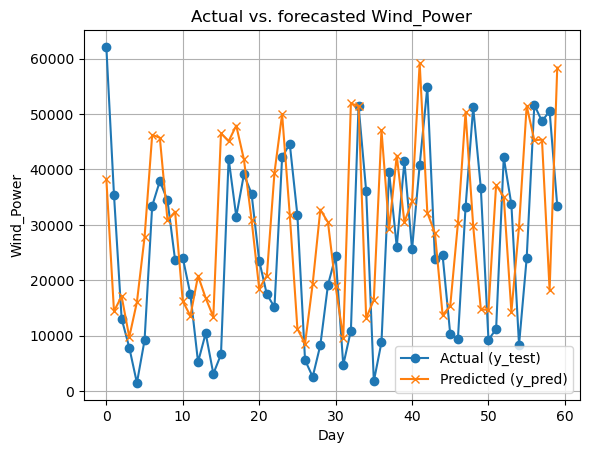

In [132]:
#test accuracy
y_test = y[train_end:train_end+test_days]

mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f' MAPE: {mape:.4f}')
print(f'R2: {r2:.4f}')



#A picture

x = np.arange(len(y_test))

plt.plot(x, y_test, marker='o', label='Actual (y_test)')
plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
plt.xlabel('Day')
plt.ylabel('Wind_Power')
plt.title('Actual vs. forecasted Wind_Power')
plt.legend()
plt.grid(True)
plt.show()

 MAPE: 1.5746
R2: -0.1583
 number ofestimators: 10.0000
 max depth: 2.0000
 Bootstrapping or not: 1.0000


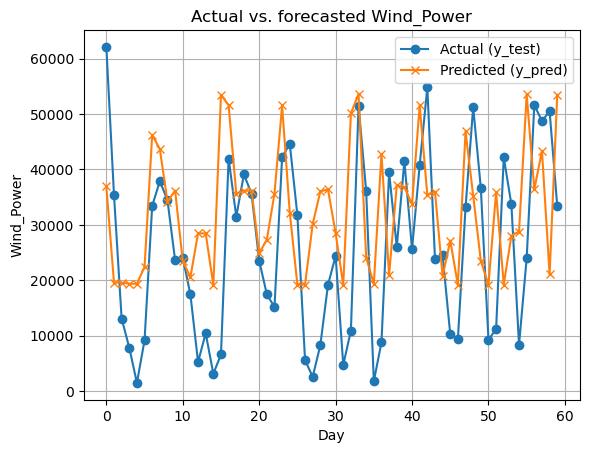

 MAPE: 1.5786
R2: -0.1616
 number ofestimators: 10.0000
 max depth: 2.0000
 Bootstrapping or not: 0.0000


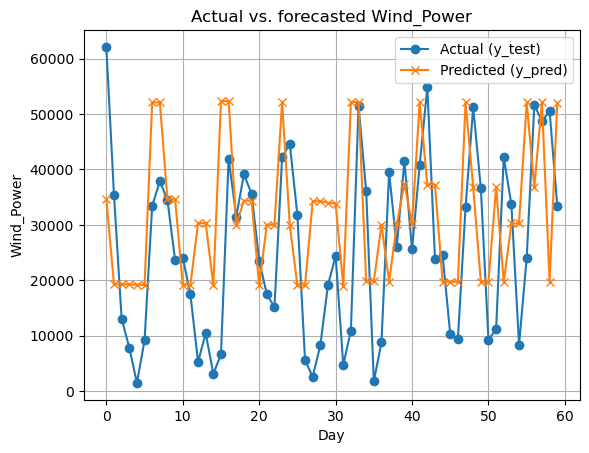

 MAPE: 1.3771
R2: -0.1631
 number ofestimators: 10.0000
 max depth: 5.0000
 Bootstrapping or not: 1.0000


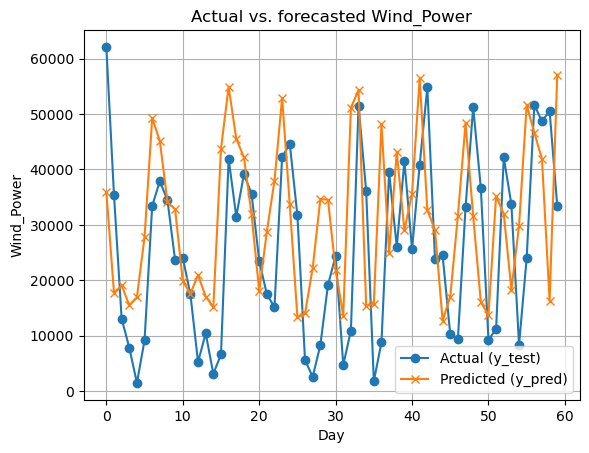

 MAPE: 1.3362
R2: -0.3342
 number ofestimators: 10.0000
 max depth: 5.0000
 Bootstrapping or not: 0.0000


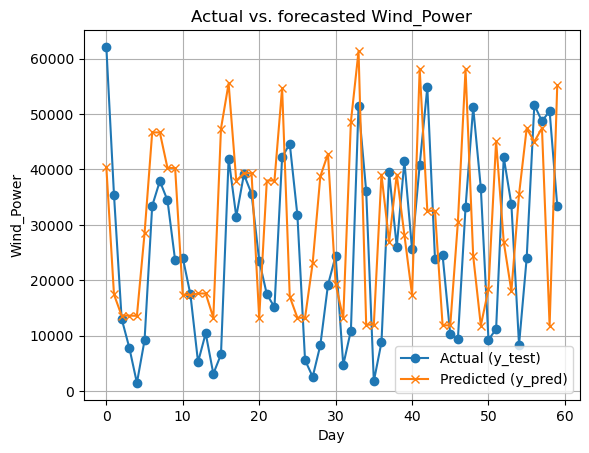

 MAPE: 1.2559
R2: -0.1530
 number ofestimators: 10.0000
 max depth: 10.0000
 Bootstrapping or not: 1.0000


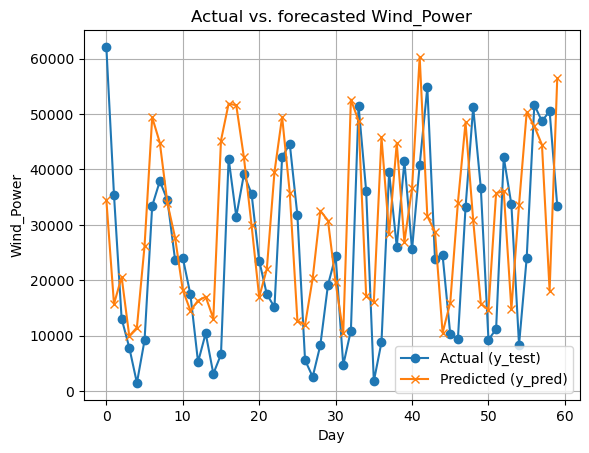

 MAPE: 1.1546
R2: -0.2525
 number ofestimators: 10.0000
 max depth: 10.0000
 Bootstrapping or not: 0.0000


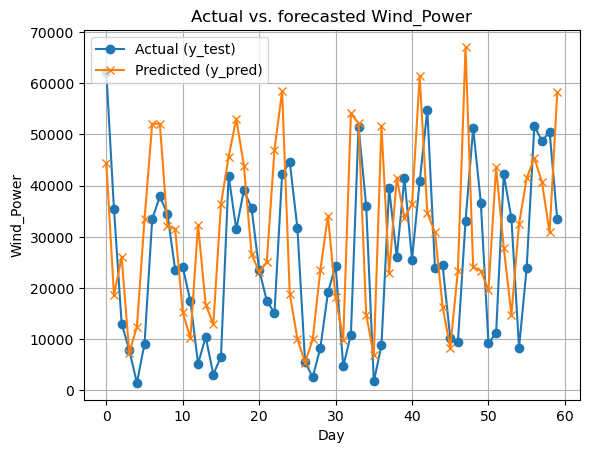

 MAPE: 1.2944
R2: -0.2034
 number ofestimators: 10.0000
 max depth: 25.0000
 Bootstrapping or not: 1.0000


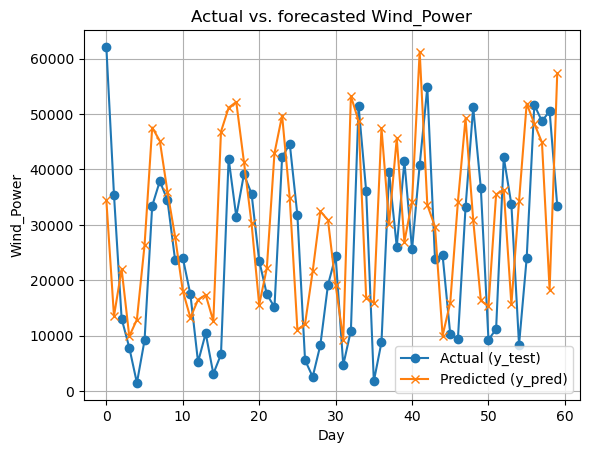

 MAPE: 1.1704
R2: -0.1998
 number ofestimators: 10.0000
 max depth: 25.0000
 Bootstrapping or not: 0.0000


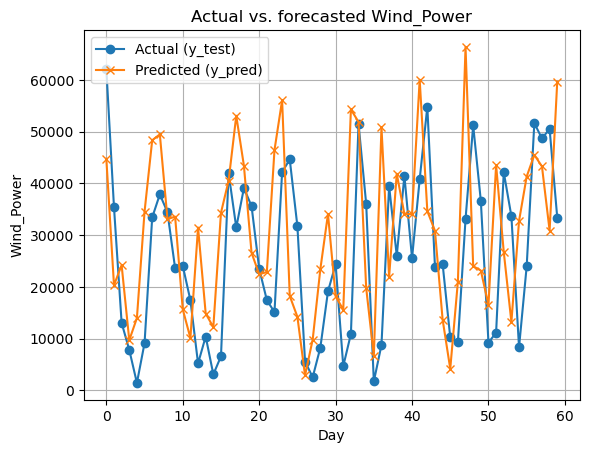

 MAPE: 1.2944
R2: -0.2034
 number ofestimators: 10.0000
 max depth: 100.0000
 Bootstrapping or not: 1.0000


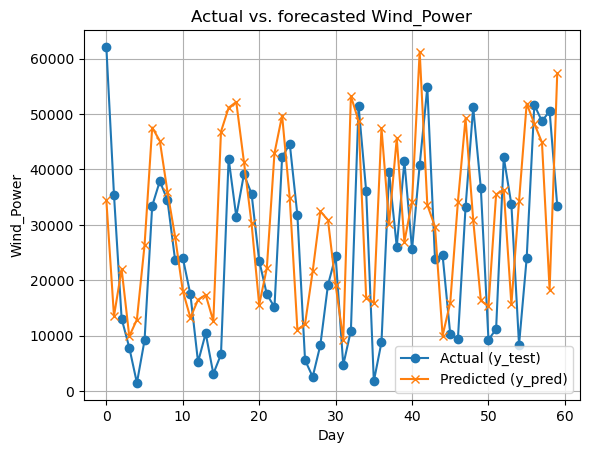

KeyboardInterrupt: 

In [26]:
# trying a variety of hyperparameters

#training data
train_start = 0 #in days, starting at midnight in Quebec
train_days =  730
test_days = 60


# Loop over all combinations
n_estimators_list = [10, 20,50, 100, 250]
max_depth_list = [2,5,10,25,100, 200]
bootstrap_list = [True, False]
#max_features_list = []#['sqrt' 'log2', None]

train_end = train_start + train_days
y_test = y[train_end:train_end+test_days]

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for bootstrap in bootstrap_list:
#                for max_features in max_features_list:
                #initialize
                mape_scores = []
                r2_scores = []
                y_pred = np.array([])
                for j in range(0, test_days):


                   X_train = X.iloc[train_start:train_end + (j)]
                   y_train = y.iloc[train_start:train_end+ (j)]



                   model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=614, bootstrap = bootstrap)#, max_features= max_features)
                   model.fit(X_train, y_train)

                   y_jth_pred = model.predict(X.iloc[[train_end+ ((j+1))]])


                   y_pred = np.append(y_pred, y_jth_pred)   
                mape = mean_absolute_percentage_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)


                print(f' MAPE: {mape:.4f}')
                print(f'R2: {r2:.4f}')
                print(f' number ofestimators: {n_estimators:.4f}')
                print(f' max depth: {max_depth:.4f}')
                print(f' Bootstrapping or not: {bootstrap:.4f}')



                #A picture

                x = np.arange(len(y_test))

                plt.plot(x, y_test, marker='o', label='Actual (y_test)')
                plt.plot(x, y_pred, marker='x', label='Predicted (y_pred)')
                plt.xlabel('Day')
                plt.ylabel('Wind_Power')
                plt.title('Actual vs. forecasted Wind_Power')
                plt.legend()
                plt.grid(True)
                plt.show()
